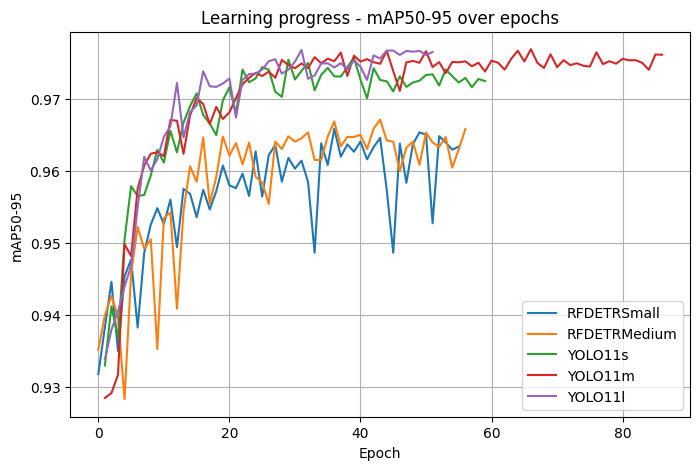

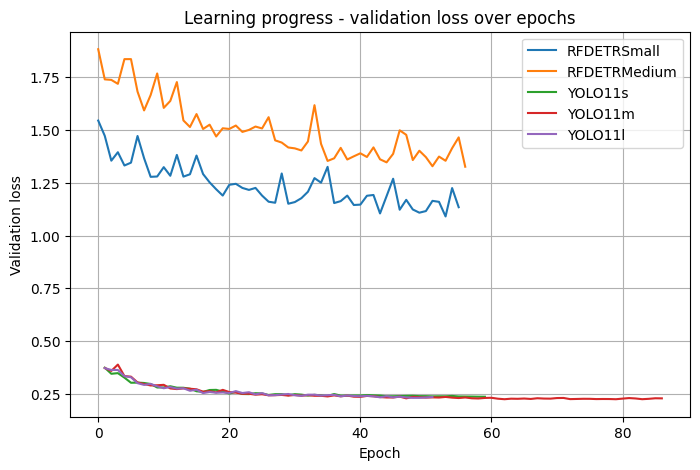

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path(".").resolve()


# ----------------------------
# Helpers
# ----------------------------

def parse_rfdetr_log(run_dir: Path, label: str):
    log_path = run_dir / "log.txt"
    assert log_path.exists(), f"Missing log file at {log_path}"

    text = log_path.read_text(encoding="utf-8")
    text = text.replace("} {", "}\n{").replace("}{", "}\n{")

    rows = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            rows.append(obj)
        except json.JSONDecodeError:
            continue

    df = pd.DataFrame(rows)
    df = df[df["epoch"].notna()].copy()
    df["epoch"] = df["epoch"].astype(int)

    def extract_map(values, idx):
        if isinstance(values, (list, tuple)) and len(values) > idx:
            return float(values[idx])
        return None

    df["map50_95"] = df["test_coco_eval_bbox"].apply(lambda v: extract_map(v, 0))
    df["map50"] = df["test_coco_eval_bbox"].apply(lambda v: extract_map(v, 1))

    return df, label


def parse_yolo_run(run_dir: Path, label: str):
    csv_path = run_dir / "yolo11s.csv"
    assert csv_path.exists(), f"Missing yolo11s.csv at {csv_path}"

    df = pd.read_csv(csv_path)
    # keep only the columns we need
    df = df[["epoch",
             "metrics/mAP50-95(B)",
             "metrics/mAP50(B)",
             "train/box_loss",
             "val/box_loss"]].copy()
    df.rename(
        columns={
            "metrics/mAP50-95(B)": "map50_95",
            "metrics/mAP50(B)": "map50",
            "train/box_loss": "train_loss",
            "val/box_loss": "val_loss",
        },
        inplace=True,
    )
    return df, label


# ----------------------------
# Load all models
# ----------------------------

# RFDETR small and medium
rfd_small_df, rfd_small_label = parse_rfdetr_log(root / "rfdetr_runs", "RFDETRSmall")
rfd_med_df, rfd_med_label = parse_rfdetr_log(root / "rfdetr_runs_medium", "RFDETRMedium")

# YOLO11 s, m, l
yolo_root = root / "yolo11_runs"
yolo_s_df, yolo_s_label = parse_yolo_run(yolo_root / "yolo11_chess", "YOLO11s")
yolo_m_df, yolo_m_label = parse_yolo_run(yolo_root / "yolo11m_chess", "YOLO11m")
yolo_l_df, yolo_l_label = parse_yolo_run(yolo_root / "yolo11l_chess", "YOLO11l")

# Put them in a list for easy looping
models = [
    (rfd_small_df, rfd_small_label),
    (rfd_med_df, rfd_med_label),
    (yolo_s_df, yolo_s_label),
    (yolo_m_df, yolo_m_label),
    (yolo_l_df, yolo_l_label),
]

# ----------------------------
# Diagram 1 - mAP50-95 over epochs
# ----------------------------

plt.figure(figsize=(8, 5))
for df, label in models:
    df_sorted = df.sort_values("epoch")
    plt.plot(df_sorted["epoch"], df_sorted["map50_95"], label=label)

plt.xlabel("Epoch")
plt.ylabel("mAP50-95")
plt.title("Learning progress - mAP50-95 over epochs")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Diagram 2 - validation loss over epochs
#   RFDETR uses test_loss, YOLO uses val_loss
#   We map both to the same name here.
# ----------------------------

plt.figure(figsize=(8, 5))
for df, label in models:
    df_sorted = df.sort_values("epoch").copy()
    # RFDETR has "test_loss", YOLO has "val_loss"
    if "test_loss" in df_sorted.columns:
        df_sorted["val_loss"] = df_sorted["test_loss"]
    plt.plot(df_sorted["epoch"], df_sorted["val_loss"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Learning progress - validation loss over epochs")
plt.grid(True)
plt.legend()
plt.show()
